In [ ]:
# ---------------------- CLEANED & FINAL IMPORTS ----------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Sklearn Models & Utilities
from sklearn.model_selection import StratifiedKFold, cross_val_score, GridSearchCV, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, StackingClassifier
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score, confusion_matrix, make_scorer
from sklearn.calibration import CalibratedClassifierCV

# XGBoost
from xgboost import XGBClassifier

# Imbalanced Data Handling
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Explainability
import shap

# Warnings
warnings.filterwarnings('ignore')

In [16]:
df=pd.read_csv("train.csv")
pd.set_option("display.max_columns",None)
display(df.head())
display(df.describe())
print("-"*60)
print("number of rows and columns",df.shape)
missing=df.isna().sum()
percentage=(missing/len(df))*100
df_null=pd.DataFrame({
    "number of null":missing,
    "percentage of missing":percentage
}).sort_values("percentage of missing" ,ascending=False)
print(df_null)
print("-"*60)
cat=df.select_dtypes(include=['object']).columns
num=df.select_dtypes(include=['int64','float64']).columns
print("name of catagorical;",cat)
print("name of numeric:",num)
print("number of catagorical;",len(cat))
print("number of numeric:",len(num))
print("-"*60)
df.info()
drop_col=percentage[percentage>50].index
df.drop(columns=drop_col,inplace=True)
df["Age"]=df["Age"].fillna(df["Age"].median())
df["Embarked"]=df["Embarked"].fillna(df["Embarked"].mode()[0])
print("-"*60)
df.isna().sum()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


------------------------------------------------------------
number of rows and columns (891, 12)
             number of null  percentage of missing
Cabin                   687              77.104377
Age                     177              19.865320
Embarked                  2               0.224467
PassengerId               0               0.000000
Name                      0               0.000000
Pclass                    0               0.000000
Survived                  0               0.000000
Sex                       0               0.000000
Parch                     0               0.000000
SibSp                     0               0.000000
Fare                      0               0.000000
Ticket                    0               0.000000
------------------------------------------------------------
name of catagorical; Index(['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked'], dtype='object')
name of numeric: Index(['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', '

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

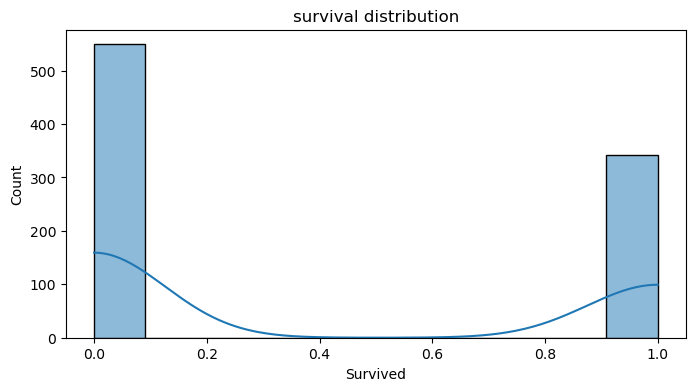

sekweenes 0.4785234382949897
kurtosis -1.775004671066304


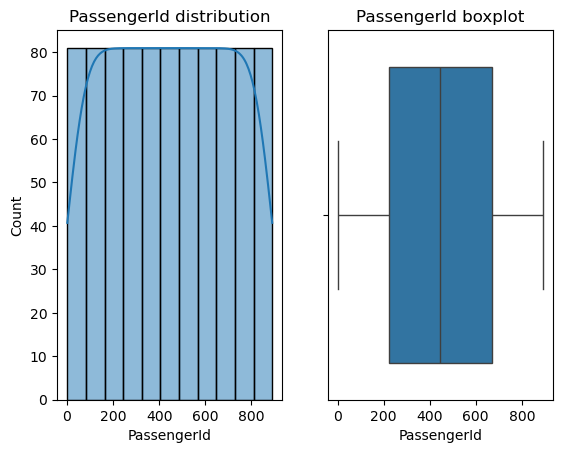

PassengerId sekweness 0.0
PassengerId kutones -1.1999999999999997


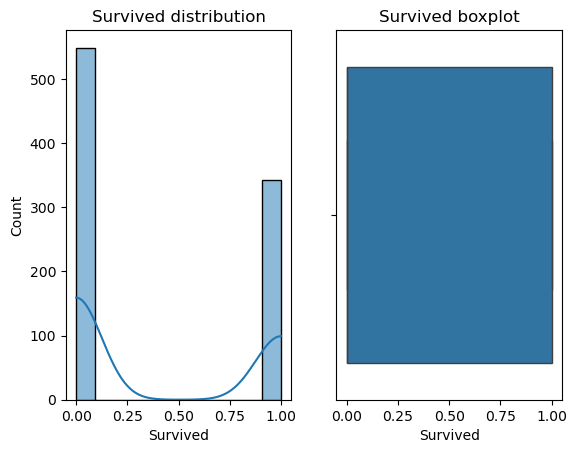

Survived sekweness 0.4785234382949897
Survived kutones -1.775004671066304


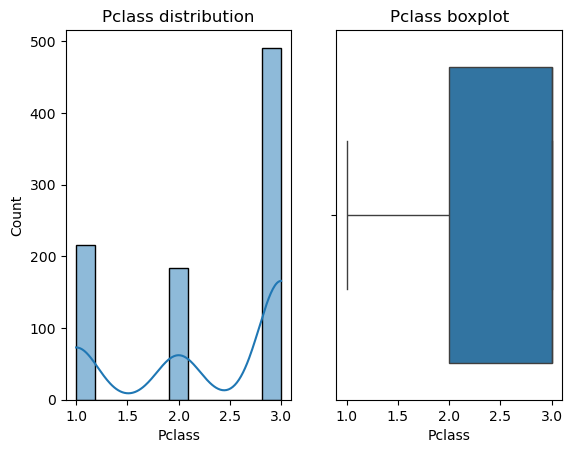

Pclass sekweness -0.6305479068752845
Pclass kutones -1.2800149715782825


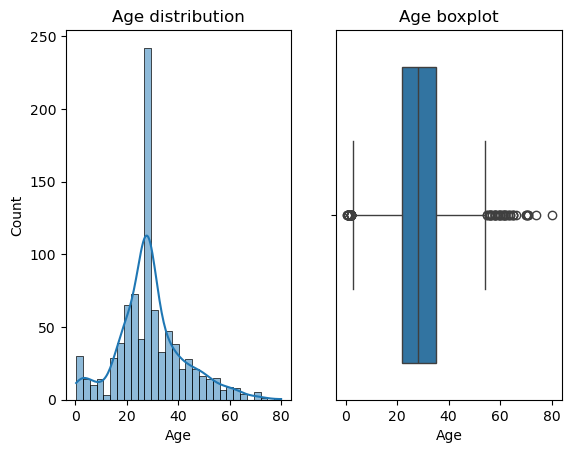

Age sekweness 0.5102446555756495
Age kutones 0.9938710163801736


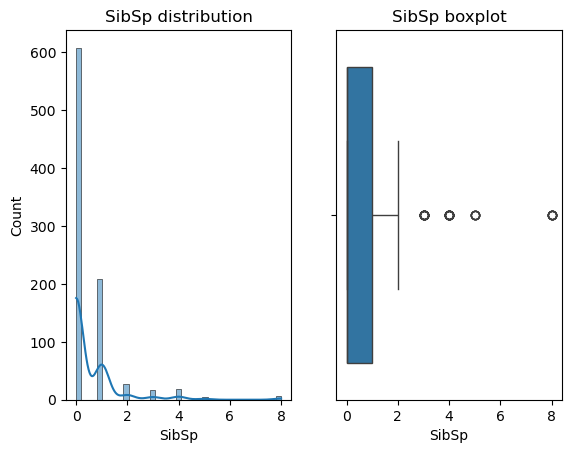

SibSp sekweness 3.6953517271630565
SibSp kutones 17.880419726645968


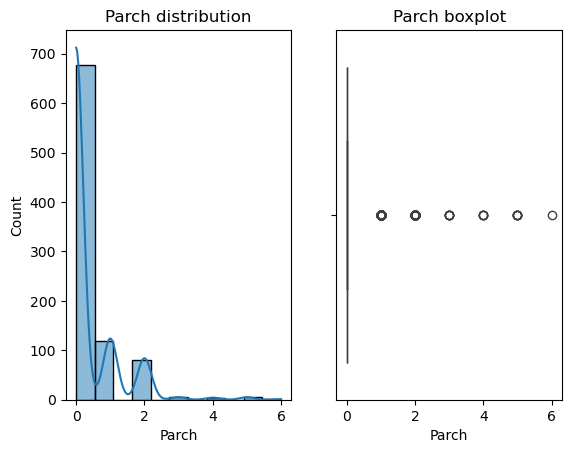

Parch sekweness 2.7491170471010933
Parch kutones 9.778125179021648


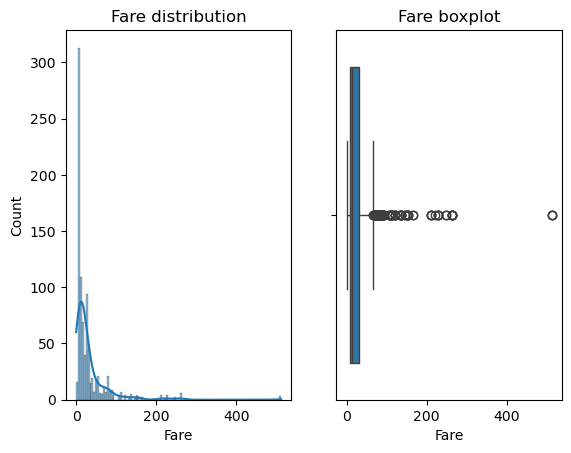

Fare sekweness 4.787316519674893
Fare kutones 33.39814088089868


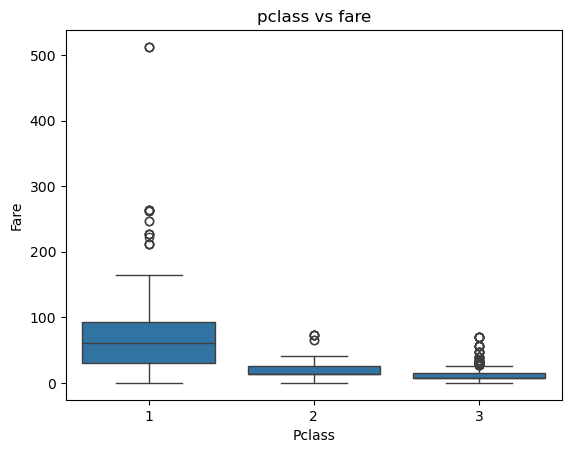

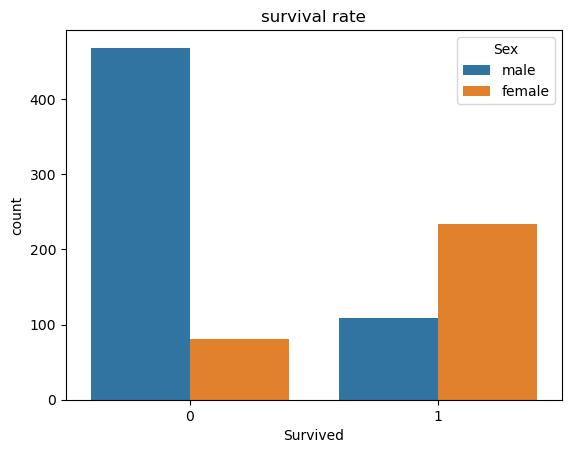

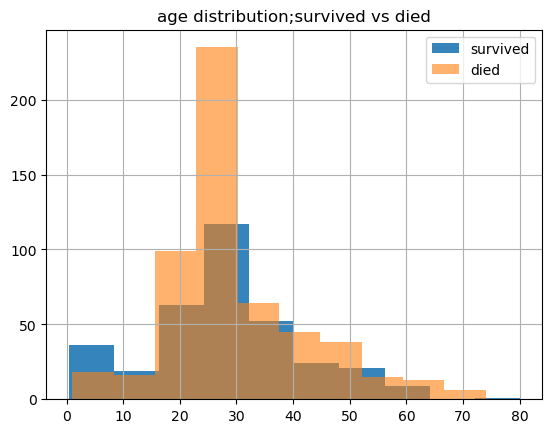

In [17]:
plt.figure(figsize=(8,4))
sns.histplot(df['Survived'],kde=True)
plt.title("survival distribution")
plt.show()
print("sekweenes",df['Survived'].skew())
print("kurtosis",df['Survived'].kurt())
for col in num:
    plt.Figure(figsize=(8,4))
    plt.subplot(1,2,1)
    sns.histplot(df[col],kde=True)
    plt.title(f"{col} distribution")
    plt.subplot(1,2,2)
    sns.boxplot(x=df[col])
    plt.title(f'{col} boxplot')
    plt.show()
    print(f"{col} sekweness",df[col].skew())
    print(f"{col} kutones",df[col].kurt())
sns.boxplot(x='Pclass',y='Fare',data=df)
plt.title("pclass vs fare")
plt.show()    
sns.countplot(x="Survived",hue='Sex',data=df)
plt.title("survival rate") 
plt.show()
df[df["Survived"]==1]['Age'].hist(alpha=0.9,label='survived')
df[df['Survived']==0]['Age'].hist(alpha=0.6,label='died')
plt.legend()
plt.title("age distribution;survived vs died")
plt.show()
       
    

In [18]:
df['FamilySize']=df['SibSp']+df['Parch']+1
df['Isalone']=(df['FamilySize']==1).astype(int)
df['age_distribution']=pd.cut(df['Age'],bins=[0,12,18,35,60,100],labels=['child','teen','young','middle','senior'])
df.drop(columns='Age',inplace=True)
df.drop(columns='SibSp',inplace=True)
df.drop(columns='Parch',inplace=True)
df.drop('PassengerId', axis=1, inplace=True)
df['Title'] = df['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)
df['Fare_per_person'] = df['Fare'] / df['FamilySize'] 
df['Fare_bin']=pd.cut(df['Fare_per_person'],bins=4,labels=['low','medium','high','ver_high'])
df.drop(columns='Name', inplace=True)
df.drop(columns='Ticket',inplace=True)
df.drop(columns='Fare',inplace=True)
for col in df.columns:
    print(f"{col} unique values:")
    print(df[col].unique())
    print("-"*40)



Survived unique values:
[0 1]
----------------------------------------
Pclass unique values:
[3 1 2]
----------------------------------------
Sex unique values:
['male' 'female']
----------------------------------------
Embarked unique values:
['S' 'C' 'Q']
----------------------------------------
FamilySize unique values:
[ 2  1  5  3  7  6  4  8 11]
----------------------------------------
Isalone unique values:
[0 1]
----------------------------------------
age_distribution unique values:
['young', 'middle', 'child', 'teen', 'senior']
Categories (5, object): ['child' < 'teen' < 'young' < 'middle' < 'senior']
----------------------------------------
Title unique values:
['Mr' 'Mrs' 'Miss' 'Master' 'Don' 'Rev' 'Dr' 'Mme' 'Ms' 'Major' 'Lady'
 'Sir' 'Mlle' 'Col' 'Capt' 'Countess' 'Jonkheer']
----------------------------------------
Fare_per_person unique values:
[  3.625       35.64165      7.925       26.55         8.05
   8.4583      51.8625       4.215        3.7111      15.0354
   5

In [19]:
ordinal_cols = ['age_distribution', 'Fare_bin']
age_map = {'child':0, 'teen':1, 'young':2, 'middle':3, 'senior':4}
fare_map = {'low':0, 'medium':1, 'high':2, 'ver_high':3}
df['age_distribution'] = df['age_distribution'].map(age_map)
df['Fare_bin'] = df['Fare_bin'].map(fare_map)
nominal_cols = ['Sex', 'Embarked', 'Title']
df = pd.get_dummies(df, columns=nominal_cols, drop_first=True)
num=df.select_dtypes(include=['int64','float64']).columns
for col in num:
    q1=df[col].quantile(0.25)
    q3=df[col].quantile(0.75)
    iqr=q3-q1
    lower = q1 - 1.5*iqr
    upper = q3 + 1.5*iqr
    median = df[col].median()
    df[col] = df[col].apply(lambda x: median if x < lower or x > upper else x)
    

In [20]:
df.columns

Index(['Survived', 'Pclass', 'FamilySize', 'Isalone', 'age_distribution',
       'Fare_per_person', 'Fare_bin', 'Sex_male', 'Embarked_Q', 'Embarked_S',
       'Title_Col', 'Title_Countess', 'Title_Don', 'Title_Dr',
       'Title_Jonkheer', 'Title_Lady', 'Title_Major', 'Title_Master',
       'Title_Miss', 'Title_Mlle', 'Title_Mme', 'Title_Mr', 'Title_Mrs',
       'Title_Ms', 'Title_Rev', 'Title_Sir'],
      dtype='object')

---- Random Forest Metrics ----
F1: 0.7703, Accuracy: 0.8101, Precision: 0.7215, Recall: 0.8261
[[88 22]
 [12 57]]

---- XGBoost Metrics ----
F1: 0.7671, Accuracy: 0.8101, Precision: 0.7273, Recall: 0.8116
[[89 21]
 [13 56]]

---- Logistic Regression Metrics ----
F1: 0.7375, Accuracy: 0.7654, Precision: 0.6484, Recall: 0.8551
[[78 32]
 [10 59]]

Best threshold for F1 (Stacked Model): 0.50

---- Final Stacked Model Metrics ----
F1: 0.7785, Accuracy: 0.8156, Precision: 0.7250, Recall: 0.8406
[[88 22]
 [11 58]]


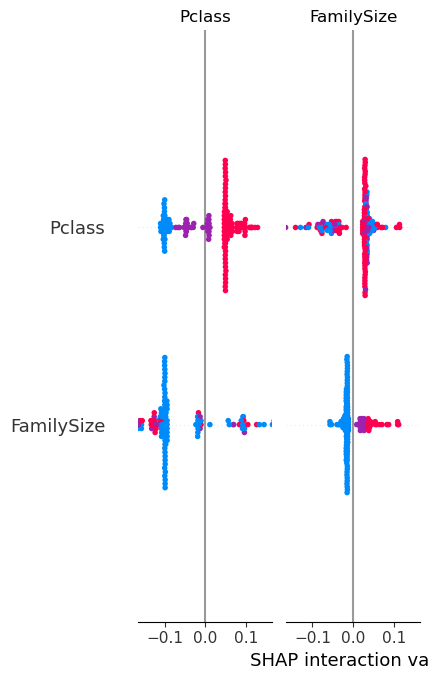

In [21]:


# ---------------------- PREPROCESSING ----------------------
# Ensure ordinal features are numeric
ordinal_cols = ['age_distribution', 'Fare_bin']
for col in ordinal_cols:
    df[col] = df[col].astype(int)

# One-hot encoding only for existing nominal columns
nominal_cols = ['Sex', 'Embarked', 'Title']
existing_nominal_cols = [col for col in nominal_cols if col in df.columns]
if existing_nominal_cols:
    df = pd.get_dummies(df, columns=existing_nominal_cols, drop_first=True)

# Features & target
X = df.drop('Survived', axis=1)
y = df['Survived']

# ---------------------- TRAIN-TEST SPLIT ----------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.2, random_state=42
)

# ---------------------- SMOTE ----------------------
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# ---------------------- CROSS-VALIDATION ----------------------
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ---------------------- RANDOM FOREST ----------------------
rf_params = {
    'n_estimators':[300,500],
    'max_depth':[4,5,7],
    'min_samples_split':[2,5],
    'min_samples_leaf':[1,2]
}
rf = RandomForestClassifier(random_state=42, class_weight='balanced')
grid_rf = GridSearchCV(rf, rf_params, cv=cv, scoring='f1', n_jobs=-1)
grid_rf.fit(X_train_res, y_train_res)
rf_best = grid_rf.best_estimator_

# RF Metrics
y_pred_rf = rf_best.predict(X_test)
print("---- Random Forest Metrics ----")
print(f"F1: {f1_score(y_test, y_pred_rf):.4f}, Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}, Precision: {precision_score(y_test, y_pred_rf):.4f}, Recall: {recall_score(y_test, y_pred_rf):.4f}")
print(confusion_matrix(y_test, y_pred_rf))

# ---------------------- XGBOOST ----------------------
scale_pos_weight = (y_train_res==0).sum() / (y_train_res==1).sum()
xgb_params = {
    'n_estimators':[100,200],
    'max_depth':[3,4,5],
    'learning_rate':[0.01,0.05,0.1],
    'subsample':[0.7,0.8,1.0],
    'colsample_bytree':[0.7,0.8,1.0]
}
xgb = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False
)
grid_xgb = GridSearchCV(xgb, xgb_params, cv=cv, scoring='f1', n_jobs=-1)
grid_xgb.fit(X_train_res, y_train_res)
xgb_best = grid_xgb.best_estimator_

# XGB Metrics
y_pred_xgb = xgb_best.predict(X_test)
print("\n---- XGBoost Metrics ----")
print(f"F1: {f1_score(y_test, y_pred_xgb):.4f}, Accuracy: {accuracy_score(y_test, y_pred_xgb):.4f}, Precision: {precision_score(y_test, y_pred_xgb):.4f}, Recall: {recall_score(y_test, y_pred_xgb):.4f}")
print(confusion_matrix(y_test, y_pred_xgb))

# ---------------------- LOGISTIC REGRESSION ----------------------
lr_params = {'C':[0.01,0.1,1,10]}
lr = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
grid_lr = GridSearchCV(lr, lr_params, cv=cv, scoring='f1', n_jobs=-1)
grid_lr.fit(X_train_res, y_train_res)
lr_best = grid_lr.best_estimator_

# LR Metrics
y_pred_lr = lr_best.predict(X_test)
print("\n---- Logistic Regression Metrics ----")
print(f"F1: {f1_score(y_test, y_pred_lr):.4f}, Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}, Precision: {precision_score(y_test, y_pred_lr):.4f}, Recall: {recall_score(y_test, y_pred_lr):.4f}")
print(confusion_matrix(y_test, y_pred_lr))

# ---------------------- STACKING ENSEMBLE ----------------------
estimators = [('lr', lr_best), ('rf', rf_best), ('xgb', xgb_best)]
stack = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(max_iter=1000),
    cv=cv,
    n_jobs=-1
)
stack_calibrated = CalibratedClassifierCV(stack, cv=cv)
stack_calibrated.fit(X_train_res, y_train_res)

# Threshold tuning
y_proba_stack = stack_calibrated.predict_proba(X_test)[:,1]
thresholds = np.arange(0.3,0.71,0.01)
f1_scores = [f1_score(y_test, (y_proba_stack>t).astype(int)) for t in thresholds]
best_thresh = thresholds[np.argmax(f1_scores)]
print(f"\nBest threshold for F1 (Stacked Model): {best_thresh:.2f}")

y_pred_stack = (y_proba_stack > best_thresh).astype(int)

# Stacked Metrics
print("\n---- Final Stacked Model Metrics ----")
print(f"F1: {f1_score(y_test, y_pred_stack):.4f}, Accuracy: {accuracy_score(y_test, y_pred_stack):.4f}, Precision: {precision_score(y_test, y_pred_stack):.4f}, Recall: {recall_score(y_test, y_pred_stack):.4f}")
print(confusion_matrix(y_test, y_pred_stack))


# ---------------------- SHAP FEATURE IMPORTANCE (Error-free) ----------------------
# Ensure all features are numeric before SHAP
X_train_shap = X_train_res.copy()
X_test_shap = X_test.copy()

# Convert all columns to numeric
for col in X_train_shap.columns:
    X_train_shap[col] = pd.to_numeric(X_train_shap[col], errors='coerce')
    X_test_shap[col] = pd.to_numeric(X_test_shap[col], errors='coerce')

# Fill any NaN just in case
X_train_shap = X_train_shap.fillna(0)
X_test_shap = X_test_shap.fillna(0)

# SHAP explainer
import shap
explainer_rf = shap.TreeExplainer(rf_best)
shap_values_rf = explainer_rf(X_test_shap)
shap.summary_plot(shap_values_rf.values, X_test_shap, plot_type="bar")

In [ ]:

# ---------------------- FEATURES & TARGET ----------------------
X = df.drop('Survived', axis=1)
y = df['Survived']

# Convert ordinal columns to int
ordinal_cols = ['age_distribution', 'Fare_bin']
for col in ordinal_cols:
    X[col] = X[col].astype(int)

# ---------------------- TRAIN-TEST SPLIT ----------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.2, random_state=42
)

# ---------------------- CROSS-VALIDATION ----------------------
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ---------------------- BASE MODELS WITH IMBLEARN PIPELINE ----------------------

# Logistic Regression pipeline
pipe_lr = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
])
param_lr = {'lr__C':[0.01, 0.1, 1, 10]}
grid_lr = GridSearchCV(pipe_lr, param_lr, cv=cv, scoring='f1', n_jobs=-1)
grid_lr.fit(X_train, y_train)
lr_best = grid_lr.best_estimator_

# Random Forest pipeline
pipe_rf = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('rf', RandomForestClassifier(random_state=42, class_weight='balanced'))
])
rf_params = {'rf__n_estimators':[300,500],'rf__max_depth':[4,5,7],
             'rf__min_samples_split':[2,5],'rf__min_samples_leaf':[1,2]}
grid_rf = GridSearchCV(pipe_rf, rf_params, cv=cv, scoring='f1', n_jobs=-1)
grid_rf.fit(X_train, y_train)
rf_best = grid_rf.best_estimator_

# Gradient Boosting pipeline
pipe_gb = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('gb', GradientBoostingClassifier(random_state=42))
])
gb_params = {'gb__n_estimators':[200,500],'gb__learning_rate':[0.01,0.05,0.1],
             'gb__max_depth':[3,4,5],'gb__subsample':[0.7,0.8,1.0]}
grid_gb = GridSearchCV(pipe_gb, gb_params, cv=cv, scoring='f1', n_jobs=-1)
grid_gb.fit(X_train, y_train)
gb_best = grid_gb.best_estimator_

# XGBoost final estimator (no SMOTE, only training features)
scale_pos_weight = (y_train==0).sum() / (y_train==1).sum()
xgb_final = XGBClassifier(
    n_estimators=200, max_depth=4, learning_rate=0.05, subsample=0.8,
    colsample_bytree=0.8, scale_pos_weight=scale_pos_weight,
    random_state=42, eval_metric='logloss', use_label_encoder=False, n_jobs=-1
)

# ---------------------- STACKING ENSEMBLE ----------------------
stack = StackingClassifier(
    estimators=[('lr', lr_best), ('rf', rf_best), ('gb', gb_best)],
    final_estimator=xgb_final,
    passthrough=True,  # original features + base model predictions
    cv=cv,
    n_jobs=-1
)
# Optional: probability calibration for more reliable threshold tuning
stack_calibrated = CalibratedClassifierCV(stack, cv=cv)
stack_calibrated.fit(X_train, y_train)

# ---------------------- THRESHOLD TUNING ----------------------
y_proba_stack = stack_calibrated.predict_proba(X_test)[:,1]
thresholds = np.arange(0.3,0.71,0.01)
f1_scores = [f1_score(y_test, (y_proba_stack>t).astype(int)) for t in thresholds]
best_thresh = thresholds[np.argmax(f1_scores)]
y_pred_final = (y_proba_stack > best_thresh).astype(int)
print(f"\nBest threshold tuned for F1: {best_thresh:.2f}")

# ---------------------- FINAL METRICS ----------------------
print("\n---- Final Stacked Model Metrics ----")
print(f"F1 Score: {f1_score(y_test, y_pred_final):.4f}")
print(f"Accuracy: {accuracy_score(y_test, y_pred_final):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_final):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_final):.4f}")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_final))


Best threshold tuned for F1: 0.31

---- Final Stacked Model Metrics ----
F1 Score: 0.7733
Accuracy: 0.8101
Precision: 0.7160
Recall: 0.8406
Confusion Matrix:
[[87 23]
 [11 58]]


In [23]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
import numpy as np
model = lr_best   # ya rf_best, gb_best, xgb_final, stack_calibrated
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

f1_scores = cross_val_score(model, X, y, cv=skf, scoring='f1')

print("F1 Scores per fold:", f1_scores)
print("Mean F1:", np.mean(f1_scores))
print("Std Dev:", np.std(f1_scores))

F1 Scores per fold: [0.76821192 0.74125874 0.76923077 0.71328671 0.77852349]
Mean F1: 0.7541023268477822
Std Dev: 0.02389650857504416


In [ ]:
def deploy_stacked_model(new_data, model=stack, threshold=best_thresh):
    """
    Input: 
        new_data -> DataFrame (same columns as training X)
        model -> trained stacked model
        threshold -> best threshold tuned for F1
    Output:
        predictions -> 0/1 array
    """
    # Ensure ordinal columns are intS
    for col in ['age_distribution', 'Fare_bin']:
        if col in new_data.columns:
            new_data[col] = new_data[col].astype(int)
    
    # Predict probabilities
    y_proba = model.predict_proba(new_data)[:,1]
    
    # Apply threshold
    predictions = (y_proba > threshold).astype(int)
    
    return predictions

# Example usage:
# new_df = pd.read_csv('future_data.csv')
# y_pred_new = deploy_stacked_model(new_df)